<a href="https://colab.research.google.com/github/tsvlgd/MLE/blob/main/advanced_ml/02-pytorch-opencv/7.%20ann-from-scratch/ann-fashion-mnist-pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [9]:
torch.manual_seed(42)

In [7]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# 1. from google.colab import drive
# drive.mount('/content/drive')
# data = pd.read_csv('/content/drive/MyDrive/data.csv')


# 2. !gdown --id 1ziN7gJHnr-MQb0_eFsPfPfiiDuvsmqVH

In [11]:
df= pd.read_csv('/content/fmnist_small.csv')

In [4]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [ ]:
df.shape

(6000, 785)

In [5]:
df.iloc[:,0].value_counts()

,count
label,
6,656
7,620
5,612
2,604
4,595
0,595
3,591
1,590
8,582


In [7]:
df.describe()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,6000.000000,6000.0,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,...,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.00000
mean,4.489667,0.0,0.003333,0.022833,0.095833,0.229667,0.380833,0.815000,2.040500,5.851500,...,34.411500,23.410833,16.781833,18.320167,23.820167,18.936833,9.157167,2.783833,0.903833,0.09300
std,2.840464,0.0,0.075210,0.457180,2.494464,4.855634,5.883755,8.964309,13.320114,24.088175,...,57.150747,48.769483,42.327168,44.743938,53.096607,46.870204,31.205610,17.486349,9.630180,2.54508
min,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,59.000000,8.250000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,9.000000,0.0,3.000000,32.000000,146.000000,224.000000,213.000000,221.000000,221.000000,222.000000,...,255.000000,249.000000,255.000000,255.000000,254.000000,255.000000,248.000000,255.000000,192.000000,97.00000


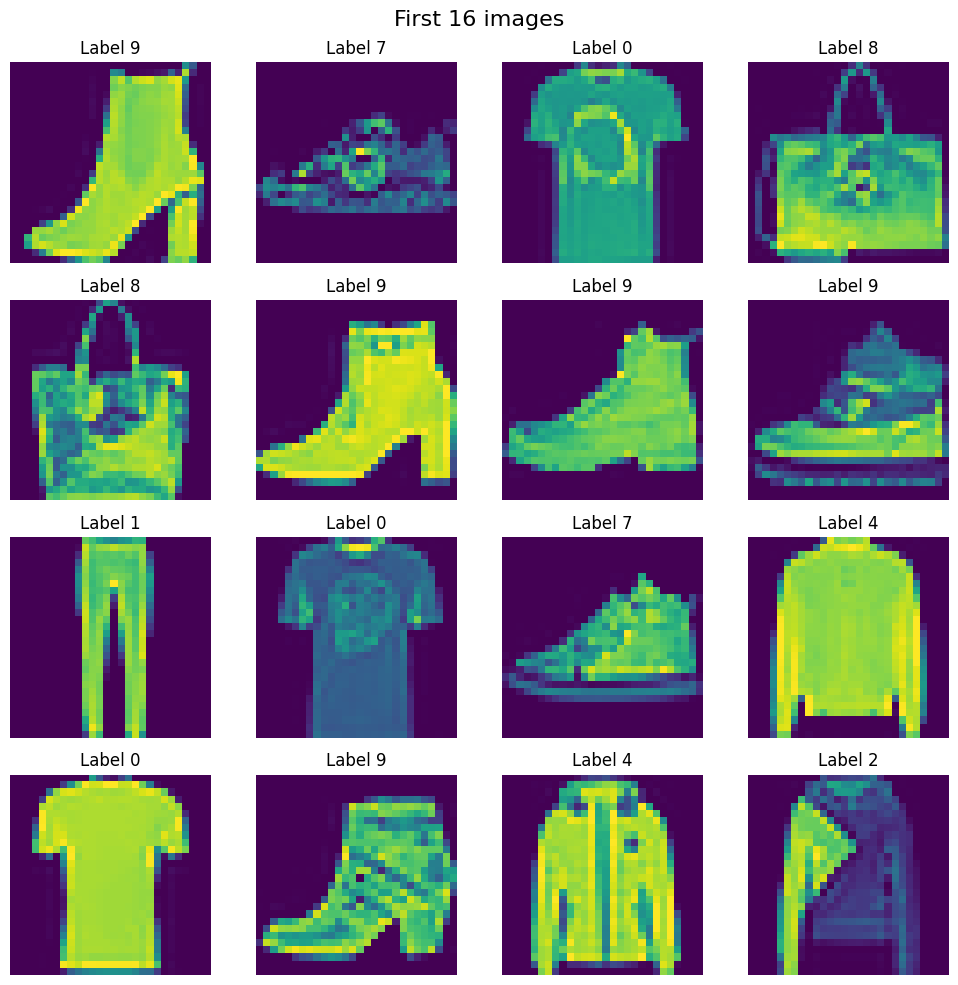

In [12]:
# 6000 samples of images (each having 784 features) -- taking the first 16 samples (16* 784)
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle('First 16 images', fontsize=16)
for i, ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape (28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label {df.iloc[i, 0]}")
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

In [13]:
# counting the null values
# 1. rows wise
df.isnull().sum(axis=1).sum()


# 2. column wise
df.isnull().sum().sum()

np.int64(0)

In [14]:
X = df.drop('label', axis=1).values
y = df['label'].values

In [ ]:
X, y

(array([[  0,   0,   0, ..., 165,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]]),
 array([9, 7, 0, ..., 8, 4, 8]))

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [17]:
# scaling the feautures
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
X_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]])

In [20]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [21]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [22]:
# create train and test loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [16]:
train_loader.__iter__().__next__()[0].shape

torch.Size([32, 784])

In [24]:
class Model(nn.Module):

  def __init__(self,num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64, 10) # for activation: there's already a softmax layer is added in loss function
    )

  def forward(self, x):

    return self.model(x)

In [ ]:
# 1. model defintion
# 2. parameters and model instansitation
# 3. trainig loop (model forward -> loss -> parameters update)

In [25]:
epochs = 100
learning_rate = 0.1

In [26]:
model = Model(X_train.shape[1])
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

`train_loader`

DataLoader Lengths Explanation
-------------------------------
`len(train_loader)` and `len(test_loader)` return the **number of batches**, not samples.
Calculated as: `number_of_batches = floor(total_samples / batch_size)`.

- If `drop_last=False` (default), the last batch may be smaller.
- If `drop_last=True`, the last incomplete batch is dropped.

Example:
- 4,800 train samples → 150 batches (batch_size=32).
- 1,200 test samples → 38 batches (last batch: 16 samples).

In [27]:
len(train_loader), len(test_loader)

(150, 38)

In [ ]:
# training loop

for epoch in range (epochs):
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    output = model(batch_features)
    batch_loss = criterion(output, batch_labels)

    # backward pass
    optimizer.zero_grad()
    batch_loss.backward()

    # update parameters
    optimizer.step()

    total_epoch_loss += batch_loss.item()

  avg_epoch_loss = total_epoch_loss / len(train_loader)
  print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_epoch_loss}")

Epoch 1/100, Loss: 1.3369920523961385
Epoch 2/100, Loss: 0.7631228222449621
Epoch 3/100, Loss: 0.6427521564563116
Epoch 4/100, Loss: 0.5707261747121811
Epoch 5/100, Loss: 0.5264454099535942
Epoch 6/100, Loss: 0.48688576102256775
Epoch 7/100, Loss: 0.45554029881954194
Epoch 8/100, Loss: 0.4377706533670425
Epoch 9/100, Loss: 0.41127018988132474
Epoch 10/100, Loss: 0.4010066231091817
Epoch 11/100, Loss: 0.38279902925093967
Epoch 12/100, Loss: 0.3639073627193769
Epoch 13/100, Loss: 0.35917372127374014
Epoch 14/100, Loss: 0.3299413264294465
Epoch 15/100, Loss: 0.3185665067533652
Epoch 16/100, Loss: 0.30628384997447333
Epoch 17/100, Loss: 0.30688674045105774
Epoch 18/100, Loss: 0.2856754978497823
Epoch 19/100, Loss: 0.27487884546319646
Epoch 20/100, Loss: 0.2664328572154045
Epoch 21/100, Loss: 0.25123802038530507
Epoch 22/100, Loss: 0.2465679859618346
Epoch 23/100, Loss: 0.23363154912988346
Epoch 24/100, Loss: 0.22773687332868575
Epoch 25/100, Loss: 0.2188415957490603
Epoch 26/100, Loss: 0.2

In [ ]:
model.eval()

Model(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
# evaluation
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)


    outputs = model(batch_features)

    predicted = torch.argmax(outputs, dim=1)

    correct += (predicted == batch_labels).sum().item()

    total += batch_labels.shape[0]

  print(f"Accuracy: {correct/total*100:.1f}")

Accuracy: 83.7


In [ ]:
len(test_loader)

38

### **Next**:  *How we can improve the accuracy of our model*
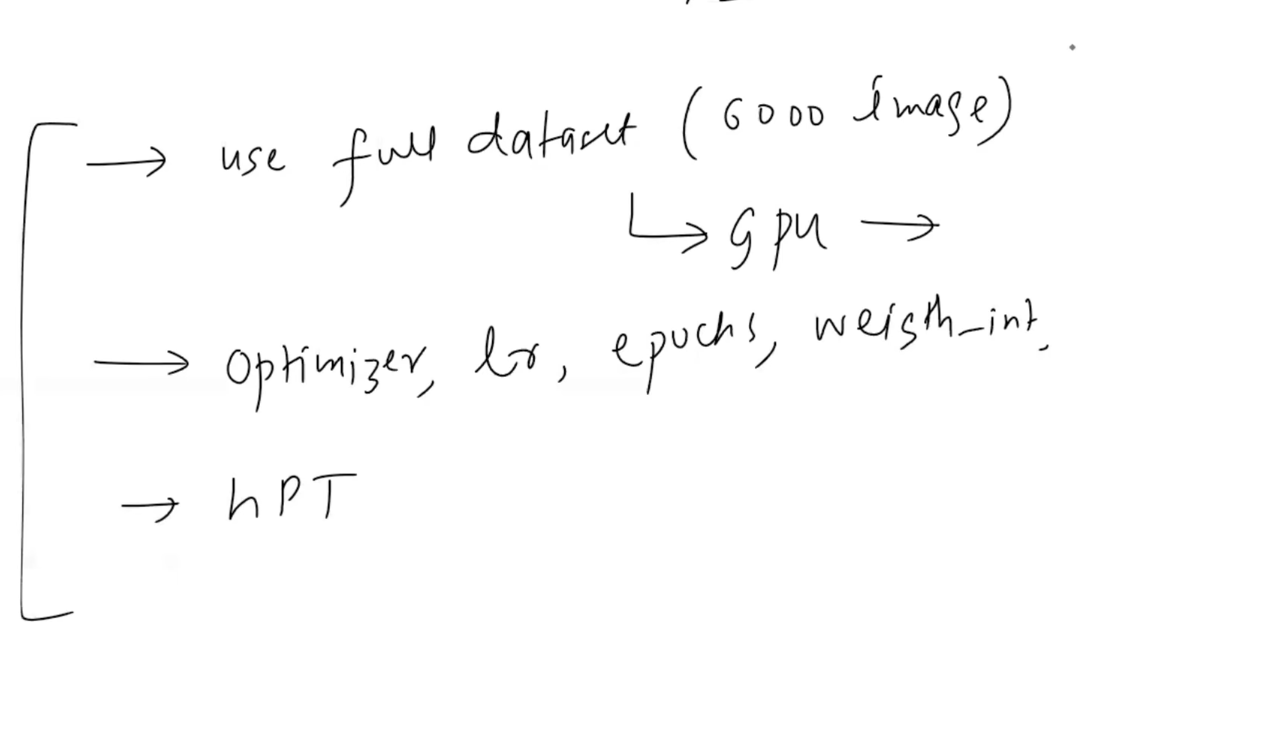